In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/MARS_ATS_1H_CONTINUOUS.csv')

print(df.shape)
df.head()

(2076, 7)


,SCLK,ATS_LOCAL_TEMP1,ATS_LOCAL_TEMP2,ATS_LOCAL_TEMP3,ATS_LOCAL_TEMP4,ATS_LOCAL_TEMP5,sol
0,7720 days 09:33:50,249.525532,270.451660,252.801554,245.416306,250.455198,1.000000
1,7721 days 10:33:50,244.340084,260.965649,243.736995,244.849724,249.347079,2.000000
2,7728 days 09:33:50,235.394630,234.195248,232.923582,239.583053,244.051231,9.000000
3,7729 days 13:33:50,244.439728,255.418648,242.270108,245.040078,250.776670,10.000000
4,7734 days 01:33:50,204.903284,205.313609,205.072629,204.643875,207.457923,14.819357


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

<Axes: >

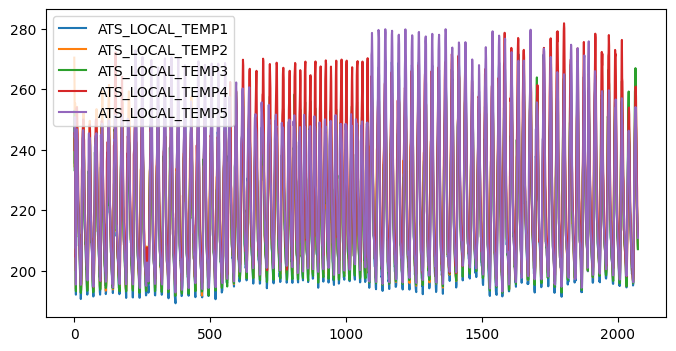

In [ ]:
df[['ATS_LOCAL_TEMP1',
    'ATS_LOCAL_TEMP2',
    'ATS_LOCAL_TEMP3',
    'ATS_LOCAL_TEMP4',
    'ATS_LOCAL_TEMP5']].plot(figsize=(8,4))

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Load dataset
df = pd.read_csv("MARS_ATS_1H_CONTINUOUS.csv")

# Select temperature columns
cols = ['ATS_LOCAL_TEMP1','ATS_LOCAL_TEMP2','ATS_LOCAL_TEMP3',
        'ATS_LOCAL_TEMP4','ATS_LOCAL_TEMP5']

data = df[cols].dropna()

# Scaling
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

# Create sequences
def create_sequences(data, time_steps=24):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:i+time_steps])
        y.append(data[i+time_steps])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, 24)

# Train test split
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model_lstm = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    LSTM(32),
    Dense(5)   # 5 output temperatures
])

model_lstm.compile(optimizer='adam', loss='mse')

history_lstm = model_lstm.fit(X_train, y_train,
                               epochs=30,
                               batch_size=32,
                               validation_data=(X_test, y_test))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 0.0775 - val_loss: 0.0323
Epoch 2/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0162 - val_loss: 0.0104
Epoch 3/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0113 - val_loss: 0.0092
Epoch 4/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0098 - val_loss: 0.0091
Epoch 5/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0093 - val_loss: 0.0086
Epoch 6/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0082 - val_loss: 0.0079
Epoch 7/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0076 - val_loss: 0.0081
Epoch 8/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0072 - val_loss: 0.0074
Epoch 9/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0068 - val_loss: 0.0077
Epoch 10/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0065 - val_loss: 0.0062
Epoch 11/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0058 - val_loss: 0.0060
Epoch 12/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0055 - v

In [ ]:
from tensorflow.keras.layers import GRU

model_gru = Sequential([
    GRU(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    GRU(32),
    Dense(5)
])

model_gru.compile(optimizer='adam', loss='mse')

history_gru = model_gru.fit(X_train, y_train,
                             epochs=30,
                             batch_size=32,
                             validation_data=(X_test, y_test))

Epoch 1/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0499 - val_loss: 0.0152
Epoch 2/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0104 - val_loss: 0.0087
Epoch 3/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0083 - val_loss: 0.0079
Epoch 4/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0077 - val_loss: 0.0071
Epoch 5/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0069 - val_loss: 0.0066
Epoch 6/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0066 - val_loss: 0.0062
Epoch 7/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0062 - val_loss: 0.0059
Epoch 8/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0058 - val_loss: 0.0055
Epoch 9/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0058 - val_loss: 0.0057
Epoch 10/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0054 - val_loss: 0.0058
Epoch 11/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0052 - val_loss: 0.0053
Epoch 12/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0050 - val_l

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

y_pred_lstm = model_lstm.predict(X_test)
y_pred_gru = model_gru.predict(X_test)

print("LSTM RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lstm)))
print("GRU RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_gru)))

print("LSTM MAE:", mean_absolute_error(y_test, y_pred_lstm))
print("GRU MAE:", mean_absolute_error(y_test, y_pred_gru))

print("LSTM R2:", r2_score(y_test, y_pred_lstm))
print("GRU R2:", r2_score(y_test, y_pred_gru))

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
LSTM RMSE: 0.0690929580233261
GRU RMSE: 0.0690886019378775
LSTM MAE: 0.044381460476982326
GRU MAE: 0.04545241017352692
LSTM R2: 0.9332117647650646
GRU R2: 0.9341932002722139


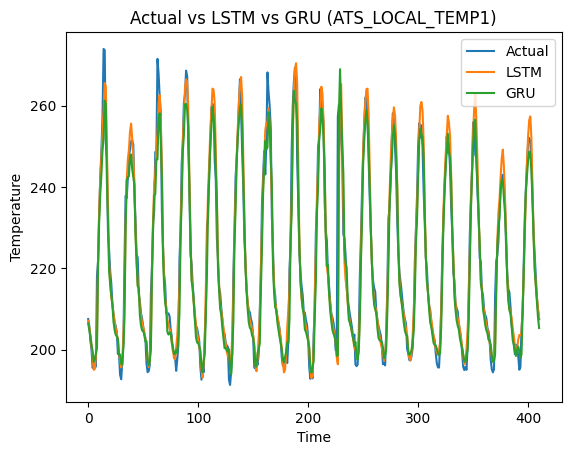

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Choose one temperature for visualization (e.g., ATS_LOCAL_TEMP1)
temp_index = 0  # 0 = TEMP1

# Inverse scaling
y_test_inv = scaler.inverse_transform(y_test)
lstm_pred_inv = scaler.inverse_transform(y_pred_lstm)
gru_pred_inv = scaler.inverse_transform(y_pred_gru)

plt.figure()
plt.plot(y_test_inv[:, temp_index])
plt.plot(lstm_pred_inv[:, temp_index])
plt.plot(gru_pred_inv[:, temp_index])
plt.title("Actual vs LSTM vs GRU (ATS_LOCAL_TEMP1)")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.legend(["Actual", "LSTM", "GRU"])
plt.show()

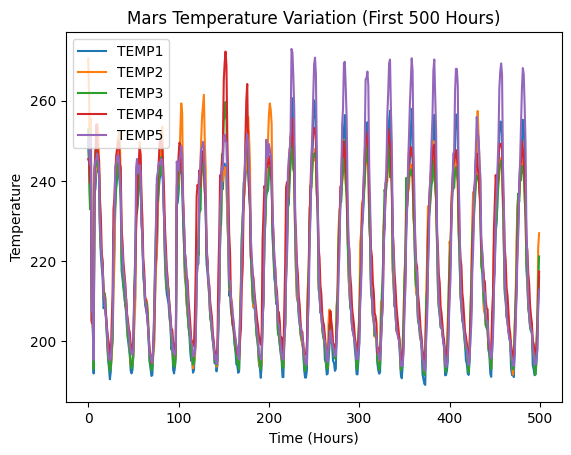

In [ ]:
plt.figure()
for i in range(5):
    plt.plot(data.iloc[:500, i])

plt.title("Mars Temperature Variation (First 500 Hours)")
plt.xlabel("Time (Hours)")
plt.ylabel("Temperature")
plt.legend([
    "TEMP1", "TEMP2", "TEMP3",
    "TEMP4", "TEMP5"
])
plt.show()

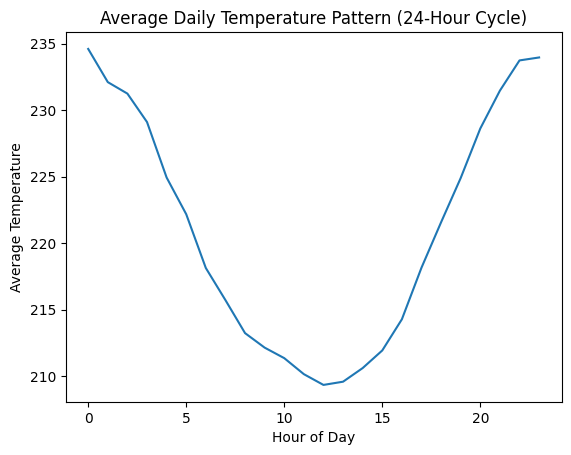

In [ ]:
# Average temperature per hour of day
df['Hour'] = df.index % 24

daily_avg = df.groupby('Hour')['ATS_LOCAL_TEMP1'].mean()

plt.figure()
plt.plot(daily_avg.values)
plt.title("Average Daily Temperature Pattern (24-Hour Cycle)")
plt.xlabel("Hour of Day")
plt.ylabel("Average Temperature")
plt.show()

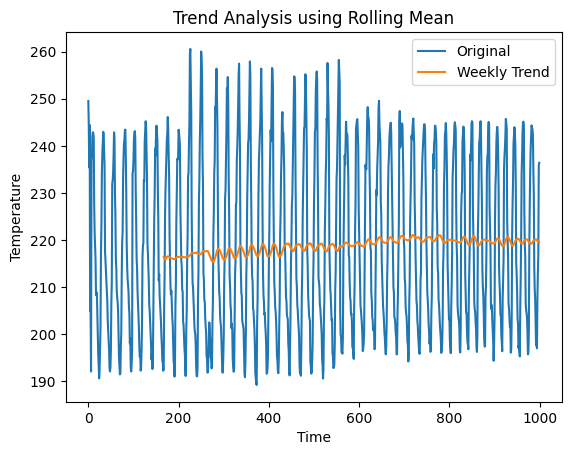

In [ ]:
rolling_mean = data['ATS_LOCAL_TEMP1'].rolling(window=168).mean()  # 168 hours = 1 week

plt.figure()
plt.plot(data['ATS_LOCAL_TEMP1'][:1000])
plt.plot(rolling_mean[:1000])
plt.title("Trend Analysis using Rolling Mean")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.legend(["Original", "Weekly Trend"])
plt.show()

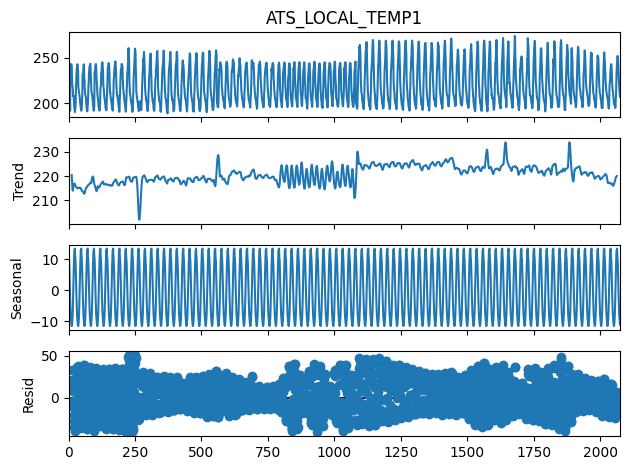

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(
    data['ATS_LOCAL_TEMP1'],
    model='additive',
    period=24
)

result.plot()
plt.show()

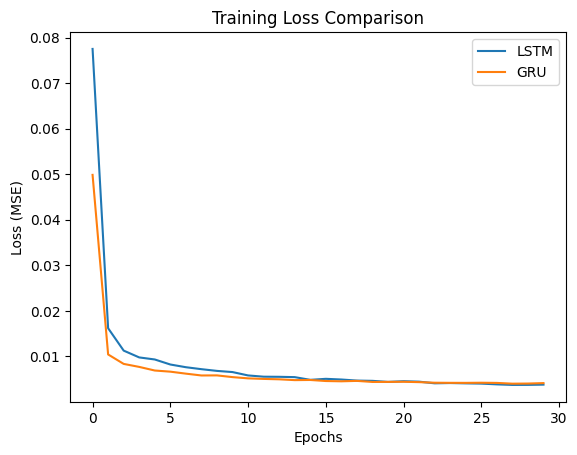

In [ ]:
plt.figure()
plt.plot(history_lstm.history['loss'])
plt.plot(history_gru.history['loss'])
plt.title("Training Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.legend(["LSTM", "GRU"])
plt.show()

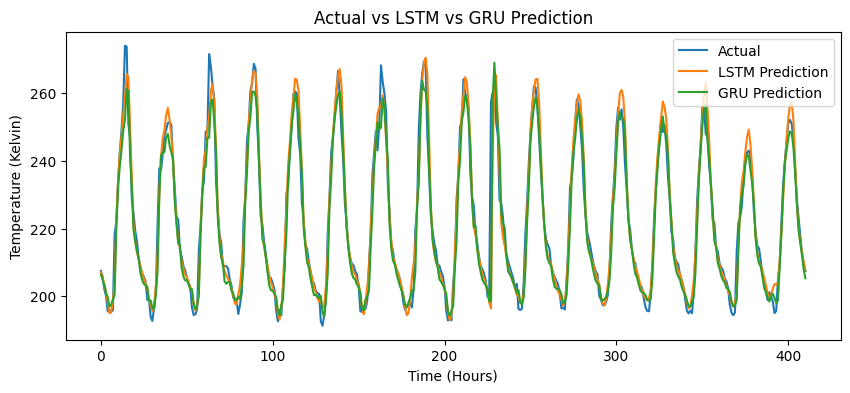

In [ ]:
import matplotlib.pyplot as plt

# Select temperature index (0 = TEMP1, 1 = TEMP2, etc.)
temp_index = 0

# Inverse scaling
y_test_inv = scaler.inverse_transform(y_test)
lstm_pred_inv = scaler.inverse_transform(y_pred_lstm)
gru_pred_inv = scaler.inverse_transform(y_pred_gru)

plt.figure(figsize=(10,4))

plt.plot(y_test_inv[:, temp_index], label='Actual')
plt.plot(lstm_pred_inv[:, temp_index], label='LSTM Prediction')
plt.plot(gru_pred_inv[:, temp_index], label='GRU Prediction')

plt.title("Actual vs LSTM vs GRU Prediction")
plt.xlabel("Time (Hours)")
plt.ylabel("Temperature (Kelvin)")
plt.legend()
plt.show()

In [ ]:
def predict_future(model, last_sequence, n_steps=24):
    future_predictions = []
    current_seq = last_sequence.copy()

    for _ in range(n_steps):
        pred = model.predict(current_seq.reshape(1, current_seq.shape[0], current_seq.shape[1]))

        future_predictions.append(pred[0])

        # update sequence (remove first, add new prediction)
        current_seq = np.vstack((current_seq[1:], pred))

    return np.array(future_predictions)

In [ ]:
# Take last sequence from dataset
last_sequence = X[-1]

# Predict next 24 hours
future_lstm = predict_future(model_lstm, last_sequence, 24)
future_gru = predict_future(model_gru, last_sequence, 24)

# Inverse scaling
future_lstm_inv = scaler.inverse_transform(future_lstm)
future_gru_inv = scaler.inverse_transform(future_gru)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━

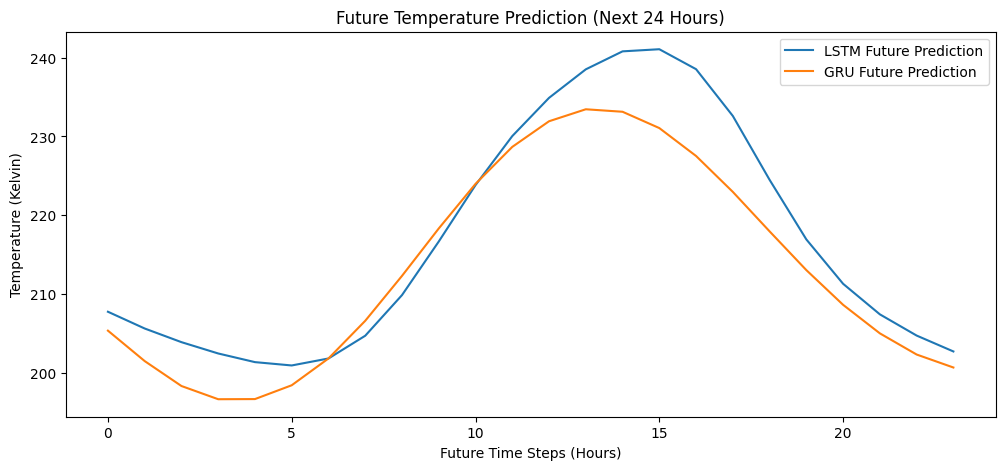

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(future_lstm_inv[:, 0], label='LSTM Future Prediction')
plt.plot(future_gru_inv[:, 0], label='GRU Future Prediction')

plt.title("Future Temperature Prediction (Next 24 Hours)")
plt.xlabel("Future Time Steps (Hours)")
plt.ylabel("Temperature (Kelvin)")
plt.legend()
plt.show()

(2076, 8)
Index(['SCLK', 'ATS_LOCAL_TEMP1', 'ATS_LOCAL_TEMP2', 'ATS_LOCAL_TEMP3',
       'ATS_LOCAL_TEMP4', 'ATS_LOCAL_TEMP5', 'sol', 'Hour'],
      dtype='object')
Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0461 - val_loss: 0.0143
Epoch 2/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0139 - val_loss: 0.0183
Epoch 3/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0113 - val_loss: 0.0155
Epoch 4/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0094 - val_loss: 0.0166
Epoch 5/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0093 - val_loss: 0.0158
Epoch 6/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0080 - val_loss: 0.0188
Epoch 1/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0390 - val_loss: 0.0084
Epoch 2/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0117 - val_loss: 0.0070
Epoch 3/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0092 - val_loss: 0.0067
Epoch 4/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0093 - val_loss: 0.0062
Epoch 5/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0079 - val_loss: 0.0058
Epoch 6/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0076 - val_loss: 0.00

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0625 - val_loss: 0.0817
Epoch 2/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0198 - val_loss: 0.0523
Epoch 3/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0161 - val_loss: 0.0189
Epoch 4/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0148 - val_loss: 0.0307
Epoch 5/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0129 - val_loss: 0.0394
Epoch 1/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0504 - val_loss: 0.0568
Epoch 2/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0159 - val_loss: 0.0218
Epoch 3/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0116 - val_loss: 0.0229
Epoch 4/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0111 - val_loss: 0.0229
Epoch 5/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0105 - val_loss: 0.0300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
      Mod

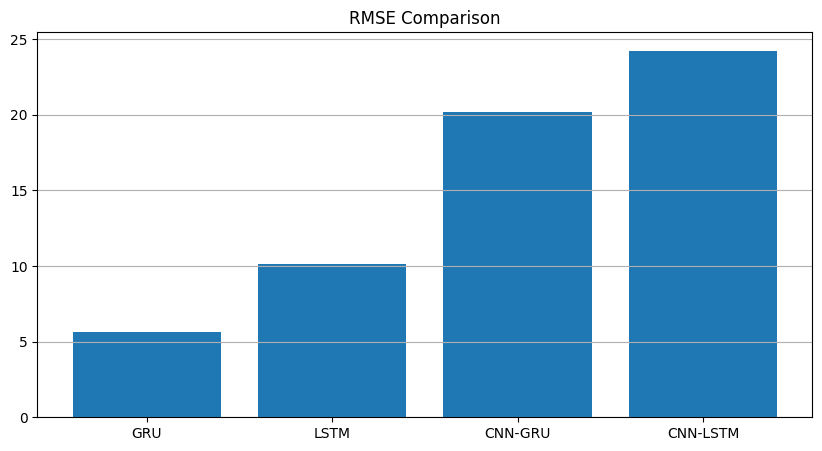

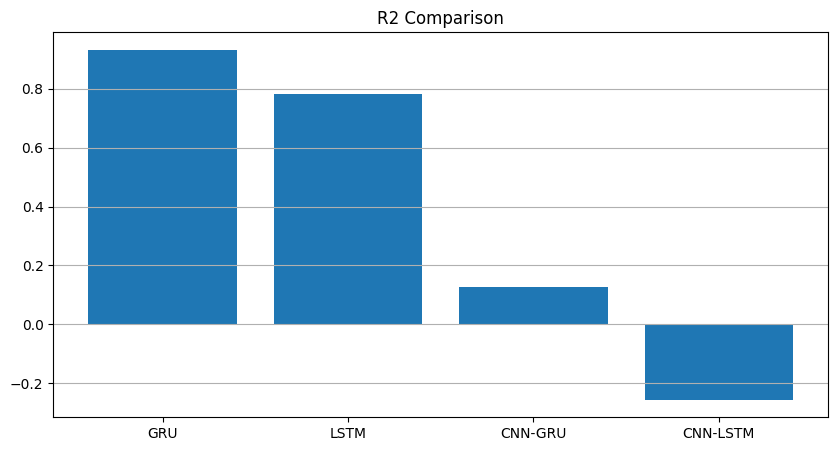

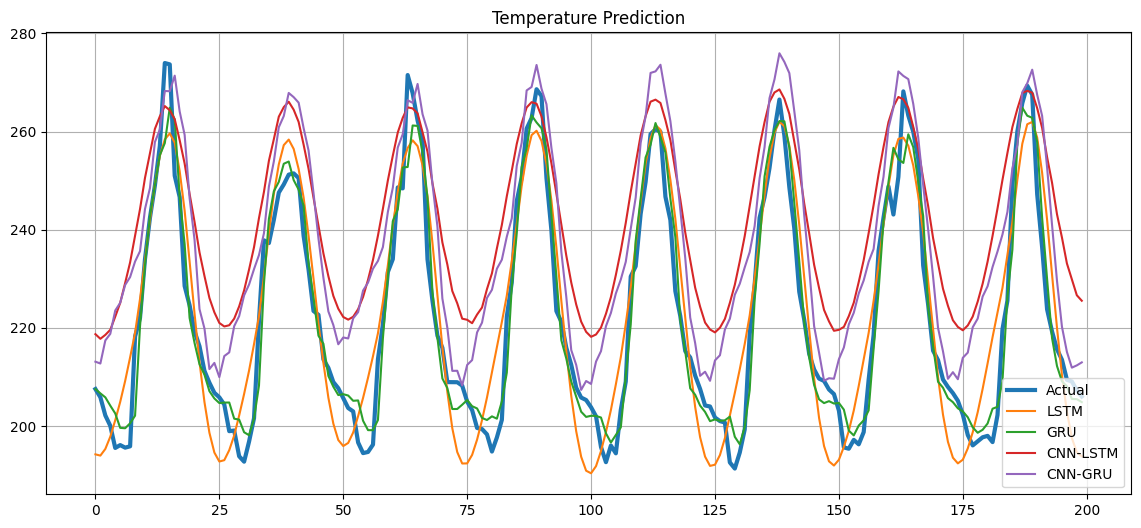

Best Model = GRU


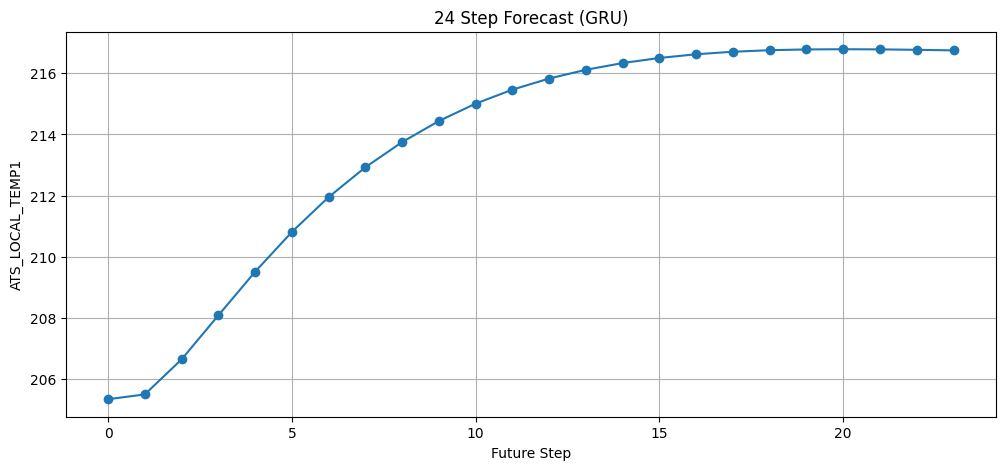

Saved: temperature_forecast.csv


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, Dropout, LSTM, GRU,
    Conv1D, MaxPooling1D
)
from tensorflow.keras.callbacks import EarlyStopping

# ==========================================================
# 1. PREPARE DATA
# ==========================================================
print(df.shape)
print(df.columns)
df["SCLK"] = pd.to_timedelta(df["SCLK"]).dt.total_seconds()

target_col = "ATS_LOCAL_TEMP1"

feature_cols = [
    "ATS_LOCAL_TEMP1",
    "ATS_LOCAL_TEMP2",
    "ATS_LOCAL_TEMP3",
    "ATS_LOCAL_TEMP4",
    "ATS_LOCAL_TEMP5",
    "sol",
    "SCLK"
]

df = df[feature_cols].dropna().reset_index(drop=True)

data = df.values

# ==========================================================
# 2. NORMALIZATION
# ==========================================================
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

# ==========================================================
# 3. CREATE SEQUENCE
# ==========================================================
seq_length = 24

X = []
y = []

for i in range(seq_length, len(data_scaled)):
    X.append(data_scaled[i-seq_length:i])
    y.append(data_scaled[i, 0])   # TEMP1 target

X = np.array(X)
y = np.array(y)

# ==========================================================
# 4. TRAIN TEST SPLIT
# ==========================================================
split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

n_features = X.shape[2]

# ==========================================================
# 5. HELPERS
# ==========================================================
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

def inverse_target(arr):
    temp = np.zeros((len(arr), data.shape[1]))
    temp[:,0] = arr.flatten()
    return scaler.inverse_transform(temp)[:,0]

def metrics(y_true, y_pred, name):
    return {
        "Model": name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }

# ==========================================================
# 6. LSTM
# ==========================================================
lstm_model = Sequential([
    LSTM(64, return_sequences=True,
         input_shape=(seq_length, n_features)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])

lstm_model.compile(optimizer="adam", loss="mse")

lstm_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# ==========================================================
# 7. GRU
# ==========================================================
gru_model = Sequential([
    GRU(64, return_sequences=True,
        input_shape=(seq_length, n_features)),
    Dropout(0.2),
    GRU(32),
    Dropout(0.2),
    Dense(1)
])

gru_model.compile(optimizer="adam", loss="mse")

gru_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# ==========================================================
# 8. CNN-LSTM
# ==========================================================
cnn_lstm_model = Sequential([
    Conv1D(64, 2, activation="relu",
           input_shape=(seq_length, n_features)),
    MaxPooling1D(2),

    LSTM(64, return_sequences=True),
    Dropout(0.2),

    LSTM(32),
    Dropout(0.2),

    Dense(1)
])

cnn_lstm_model.compile(optimizer="adam", loss="mse")

cnn_lstm_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# ==========================================================
# 9. CNN-GRU
# ==========================================================
cnn_gru_model = Sequential([
    Conv1D(64, 2, activation="relu",
           input_shape=(seq_length, n_features)),
    MaxPooling1D(2),

    GRU(64, return_sequences=True),
    Dropout(0.2),

    GRU(32),
    Dropout(0.2),

    Dense(1)
])

cnn_gru_model.compile(optimizer="adam", loss="mse")

cnn_gru_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# ==========================================================
# 10. PREDICTIONS
# ==========================================================
y_true = inverse_target(y_test.reshape(-1,1))

pred_lstm = inverse_target(lstm_model.predict(X_test))
pred_gru = inverse_target(gru_model.predict(X_test))
pred_cnn_lstm = inverse_target(cnn_lstm_model.predict(X_test))
pred_cnn_gru = inverse_target(cnn_gru_model.predict(X_test))

# ==========================================================
# 11. RESULTS TABLE
# ==========================================================
results = pd.DataFrame([
    metrics(y_true, pred_lstm, "LSTM"),
    metrics(y_true, pred_gru, "GRU"),
    metrics(y_true, pred_cnn_lstm, "CNN-LSTM"),
    metrics(y_true, pred_cnn_gru, "CNN-GRU")
])

results = results.sort_values(
    by=["RMSE", "R2"],
    ascending=[True, False]
).reset_index(drop=True)

print(results)

# ==========================================================
# 12. COMPARISON GRAPH
# ==========================================================
plt.figure(figsize=(10,5))
plt.bar(results["Model"], results["RMSE"])
plt.title("RMSE Comparison")
plt.grid(axis="y")
plt.show()

plt.figure(figsize=(10,5))
plt.bar(results["Model"], results["R2"])
plt.title("R2 Comparison")
plt.grid(axis="y")
plt.show()

# ==========================================================
# 13. ACTUAL VS PREDICTED
# ==========================================================
plt.figure(figsize=(14,6))

plt.plot(y_true[:200], label="Actual", linewidth=3)
plt.plot(pred_lstm[:200], label="LSTM")
plt.plot(pred_gru[:200], label="GRU")
plt.plot(pred_cnn_lstm[:200], label="CNN-LSTM")
plt.plot(pred_cnn_gru[:200], label="CNN-GRU")

plt.legend()
plt.grid()
plt.title("Temperature Prediction")
plt.show()

# ==========================================================
# 14. BEST MODEL
# ==========================================================
best_name = results.iloc[0]["Model"]

print("Best Model =", best_name)

if best_name == "LSTM":
    best_model = lstm_model
elif best_name == "GRU":
    best_model = gru_model
elif best_name == "CNN-LSTM":
    best_model = cnn_lstm_model
else:
    best_model = cnn_gru_model

# ==========================================================
# 15. NEXT 24 STEP FORECAST
# ==========================================================
future_steps = 24

last_seq = data_scaled[-seq_length:]
current_seq = last_seq.reshape(1, seq_length, n_features)

future = []

for i in range(future_steps):

    pred = best_model.predict(current_seq, verbose=0)
    future.append(pred[0,0])

    new_row = current_seq[0,-1,:].copy()
    new_row[0] = pred[0,0]

    current_seq = np.append(
        current_seq[:,1:,:],
        new_row.reshape(1,1,n_features),
        axis=1
    )

future = inverse_target(np.array(future).reshape(-1,1))

# ==========================================================
# 16. FORECAST GRAPH
# ==========================================================
plt.figure(figsize=(12,5))
plt.plot(future, marker="o")
plt.title(f"24 Step Forecast ({best_name})")
plt.xlabel("Future Step")
plt.ylabel("ATS_LOCAL_TEMP1")
plt.grid()
plt.show()

# ==========================================================
# 17. SAVE CSV
# ==========================================================
pd.DataFrame({
    "Step": np.arange(1, future_steps+1),
    "Predicted_TEMP1": future
}).to_csv("temperature_forecast.csv", index=False)

print("Saved: temperature_forecast.csv")